In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.21.0
GPU available: False


In [3]:
import sys
sys.path.insert(0, '..')
from src.preprocessing.data_loader import get_class_distribution, plot_class_distribution, plot_sample_images

DATA_DIR = '../dataset/raw'
dist = get_class_distribution(DATA_DIR)

for split, classes in dist.items():
    print(f"\n{split.upper()}:")
    for cls, count in classes.items():
        print(f"  {cls:15s}: {count:5d} images")
        


TRAIN:
  NORMAL         :  1341 images
  PNEUMONIA      :  3875 images

VAL:
  NORMAL         :     8 images
  PNEUMONIA      :     8 images

TEST:
  NORMAL         :   234 images
  PNEUMONIA      :   390 images


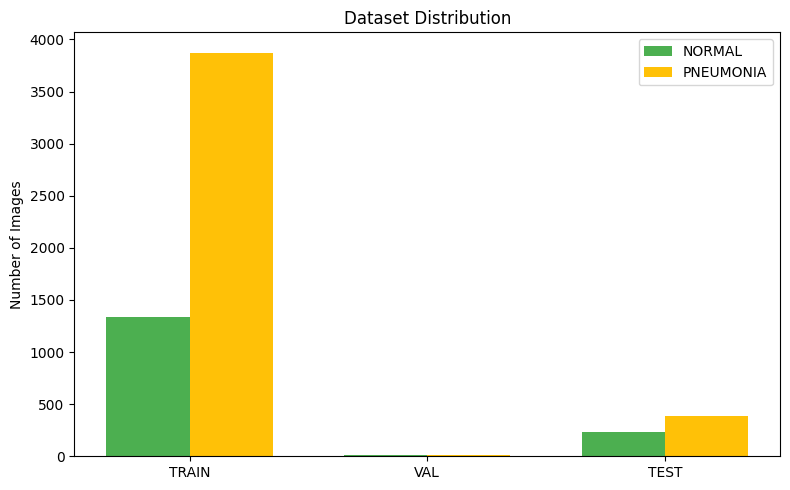

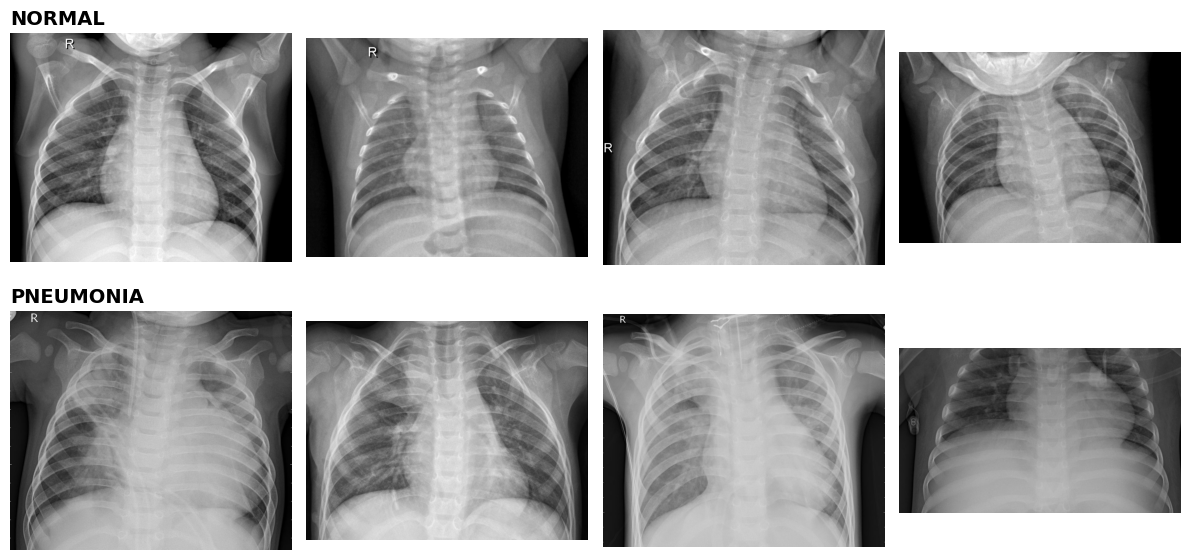

In [4]:
plot_class_distribution(DATA_DIR)
plot_sample_images(DATA_DIR, n_per_class=4)

In [5]:
from src.preprocessing.data_loader import get_data_generators

train_gen, val_gen, test_gen = get_data_generators(DATA_DIR)

print('Train batches:', len(train_gen))
print('Val   batches:', len(val_gen))
print('Test  batches:', len(test_gen))
print('Classes:', train_gen.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train batches: 163
Val   batches: 1
Test  batches: 20
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


In [6]:
from src.training.model import custom_cnn, compile_model

cnn_model = custom_cnn(num_classes=2)
cnn_model = compile_model(cnn_model, learning_rate=1e-3)
cnn_model.summary()

c:\Users\NAZEER\OneDrive\Documents\MEDISCAN_PROJECT\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,310,754 (5.00 MB)

 Trainable params: 1,307,810 (4.99 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]

In [12]:
print('Phase 1: Training classifier head...')
history_phase1 = mobile_model.fit(
    train_gen, 
    epochs=15, 
    validation_data=val_gen, 
    callbacks=callbacks, 
    verbose=1
)

Phase 1: Training classifier head...
Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 719ms/step - accuracy: 0.9507 - loss: 0.3628 - val_accuracy: 0.5625 - val_loss: 1.0440 - learning_rate: 0.0010
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 747ms/step - accuracy: 0.9530 - loss: 0.3010 - val_accuracy: 0.7500 - val_loss: 0.6404 - learning_rate: 0.0010
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 739ms/step - accuracy: 0.9565 - loss: 0.2529 - val_accuracy: 0.7500 - val_loss: 0.8286 - learning_rate: 0.0010
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 120s 737ms/step - accuracy: 0.9523 - loss: 0.2354 - val_accuracy: 0.9375 - val_loss: 0.2710 - learning_rate: 0.0010
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 742ms/step - accuracy: 0.9588 - loss: 0.2061 - val_accuracy: 0.8750 - val_loss: 0.3306 - learning_rate: 0.0010
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 120s 736ms/step - accuracy: 0.9542 - loss: 0.2016 - val_accuracy: 0.6875 - val_loss: 0.8761 - learning_rate: 0.0010
Epoch 7/15
163/163 ━━━━━━━━

In [14]:
from src.training.model import unfreeze_mobilenet

# Unfreeze from layer 100 onwards
mobile_model = unfreeze_mobilenet(mobile_model, base_model, fine_tune_at=100)

# Re-compile with a lower learning rate for fine-tuning
mobile_model = compile_model(mobile_model, learning_rate=1e-5)

In [15]:
print('Phase 2: Fine-tuning...')
history_phase2 = mobile_model.fit(
    train_gen, 
    epochs=20, 
    validation_data=val_gen, 
    callbacks=callbacks, 
    verbose=1
)

Phase 2: Fine-tuning...
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 161s 911ms/step - accuracy: 0.9099 - loss: 0.3174 - val_accuracy: 0.5625 - val_loss: 2.9139 - learning_rate: 1.0000e-05
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 876ms/step - accuracy: 0.9394 - loss: 0.2279 - val_accuracy: 0.5000 - val_loss: 4.3445 - learning_rate: 1.0000e-05
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - accuracy: 0.9451 - loss: 0.2094
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
163/163 ━━━━━━━━━━━━━━━━━━━━ 147s 901ms/step - accuracy: 0.9457 - loss: 0.2093 - val_accuracy: 0.5000 - val_loss: 4.2017 - learning_rate: 1.0000e-05
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 151s 924ms/step - accuracy: 0.9467 - loss: 0.2015 - val_accuracy: 0.5625 - val_loss: 3.4925 - learning_rate: 5.0000e-06
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 145s 886ms/step - accuracy: 0.9534 - loss: 0.1816 - val_accuracy: 0.6250 - val_loss: 2.7135 - learning_rate: 5.0000e-06
Epoch 6/20
163/163 ━━━━

In [16]:
import json

# Create the save directory if it doesn't exist
os.makedirs('../model/saved', exist_ok=True)

# Save the trained model
mobile_model.save('../model/saved/mobilenet_latest.h5')

# Save class indices
with open('../model/saved/class_indices.json', 'w') as f:
    json.dump({'0': 'NORMAL', '1': 'PNEUMONIA'}, f)

print('Model and class indices saved successfully!')

Model and class indices saved successfully!


In [17]:
from src.evaluation.evaluate import evaluate_model

metrics, y_true, y_pred, y_prob = evaluate_model('../model/saved/mobilenet_latest.h5', DATA_DIR)

Loading model from ../model/saved/mobilenet_latest.h5...


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Evaluating model on test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 774ms/step

--- Test Metrics Evaluation ---
              precision    recall  f1-score   support

      NORMAL       1.00      0.22      0.36       234
   PNEUMONIA       0.68      1.00      0.81       390

    accuracy                           0.71       624
   macro avg       0.84      0.61      0.58       624
weighted avg       0.80      0.71      0.64       624

ROC AUC Score: 0.9628
Confusion Matrix:
[[ 51 183]
 [  0 390]]


In [19]:
import cv2
from src.gradcam.gradcam import GradCAM
from src.preprocessing.data_loader import preprocess_image

# Select a sample pneumonia image from your test dataset
TEST_IMG = '../dataset/raw/test/PNEUMONIA/person1_bacteria_1.jpeg'

# Initialize Grad-CAM and preprocess the image
cam = GradCAM(mobile_model)
img_array = preprocess_image(TEST_IMG)

# Load the original image for plotting
original_np = cv2.imread(TEST_IMG)
original_np = cv2.cvtColor(original_np, cv2.COLOR_BGR2RGB)
original_np = cv2.resize(original_np, (224, 224))

# Generate and save the visualization
fig = cam.visualize(
    img_array, 
    original_np, 
    class_names=['NORMAL', 'PNEUMONIA'],
    save_path='../reports/gradcam_example.png'
)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/raw/test/PNEUMONIA/person1_bacteria_1.jpeg'